# 14 - WELFake Multinomial Naive Bayes

Outputs are saved to `reports/14_welfake_naive_bayes/` and `models/nb_welfake_model.pkl`.
confusion matrix, training time, and model persistence.

Outputs are saved to `reports/04_naive_bayes/` and `models/naive_bayes_model.pkl`.


In [8]:
import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
REPORT_DIR = ROOT / "reports" / "14_welfake_naive_bayes"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")
LABELS = ["REAL (0)", "FAKE (1)"]


In [9]:
X_train = joblib.load(DATA_DIR / "welfake/X_train_tfidf.pkl")
X_val = joblib.load(DATA_DIR / "welfake/X_val_tfidf.pkl")
y_train = np.array(joblib.load(DATA_DIR / "welfake/y_train.pkl"))
y_val = np.array(joblib.load(DATA_DIR / "welfake/y_val.pkl"))

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"X_train: {X_train.shape} | X_val: {X_val.shape}")
print("Train labels:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Val labels  :", dict(zip(*np.unique(y_val, return_counts=True))))


Data directory: C:\Users\sf\Documents\GitHub\Fake-News-Detection\data
X_train: (50451, 5000) | X_val: (10811, 5000)
Train labels: {np.int64(0): np.int64(24519), np.int64(1): np.int64(25932)}
Val labels  : {np.int64(0): np.int64(5254), np.int64(1): np.int64(5557)}


In [10]:
param_grid = {
    "alpha": [0.01, 0.1, 0.5, 1.0, 2.0],
    "fit_prior": [True, False],
}

grid_search = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

start_time = time.time()
grid_search.fit(X_train, y_train)
training_time = time.time() - start_time

print(f"Training/GridSearch time: {training_time:.2f} seconds")
print("Best params:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Training/GridSearch time: 5.37 seconds
Best params: {'alpha': 0.01, 'fit_prior': True}
Best CV accuracy: 0.8465


In [11]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_pred)
val_f1_weighted = f1_score(y_val, y_pred, average="weighted")
report_dict = classification_report(y_val, y_pred, target_names=LABELS, output_dict=True)
report_text = classification_report(y_val, y_pred, target_names=LABELS)
cm = confusion_matrix(y_val, y_pred)

print(report_text)
print(f"Validation accuracy: {val_accuracy:.4f}")
print(f"Validation weighted F1: {val_f1_weighted:.4f}")
print(cm)


              precision    recall  f1-score   support

    REAL (0)       0.86      0.81      0.83      5254
    FAKE (1)       0.83      0.87      0.85      5557

    accuracy                           0.84     10811
   macro avg       0.84      0.84      0.84     10811
weighted avg       0.84      0.84      0.84     10811

Validation accuracy: 0.8416
Validation weighted F1: 0.8414
[[4255  999]
 [ 713 4844]]


In [12]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results.to_csv(REPORT_DIR / "gridsearch_results.csv", index=False)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(REPORT_DIR / "classification_report.csv")

metrics = {
    "best_params": grid_search.best_params_,
    "best_cv_accuracy": float(grid_search.best_score_),
    "validation_accuracy": float(val_accuracy),
    "validation_f1_weighted": float(val_f1_weighted),
    "training_time_seconds": float(training_time),
    "confusion_matrix": cm.tolist(),
}
with open(REPORT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

with open(REPORT_DIR / "training_log.txt", "w", encoding="utf-8") as f:
    f.write(f"Training/GridSearch time: {training_time:.2f} seconds\n")
    f.write(f"Best params: {grid_search.best_params_}\n")
    f.write(f"Best CV accuracy: {grid_search.best_score_:.6f}\n")
    f.write(f"Validation accuracy: {val_accuracy:.6f}\n")
    f.write(f"Validation weighted F1: {val_f1_weighted:.6f}\n\n")
    f.write(report_text)

model_path = MODELS_DIR / "nb_welfake_model.pkl"
joblib.dump(best_model, model_path, compress=3)
print("Saved model:", model_path)
print("Saved reports:", REPORT_DIR)


Saved model: c:\Users\sf\Documents\GitHub\Fake-News-Detection\models\nb_welfake_model.pkl
Saved reports: c:\Users\sf\Documents\GitHub\Fake-News-Detection\reports\14_welfake_naive_bayes


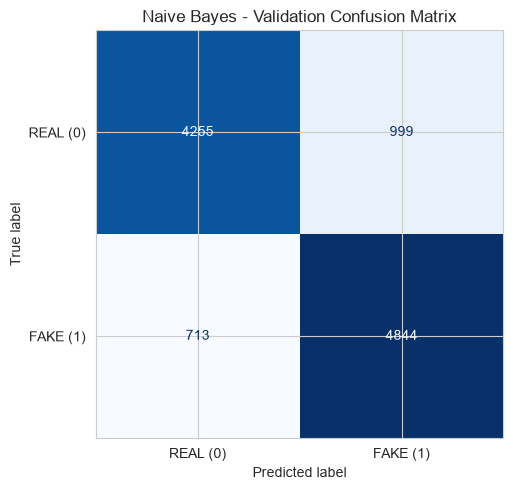

In [13]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax, values_format="d", colorbar=False)
ax.set_title("Naive Bayes - Validation Confusion Matrix")
plt.tight_layout()
plt.savefig(REPORT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


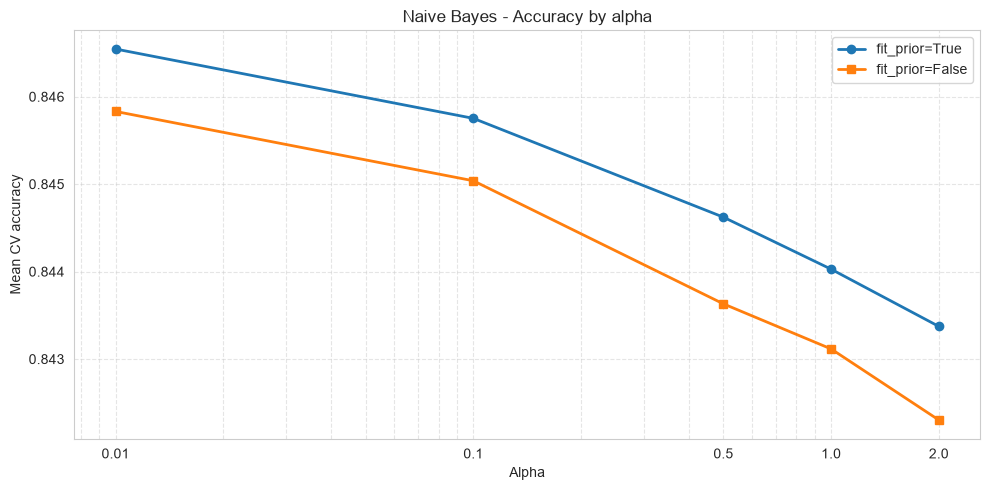

In [14]:
results_true = cv_results[cv_results["param_fit_prior"] == True].sort_values("param_alpha")
results_false = cv_results[cv_results["param_fit_prior"] == False].sort_values("param_alpha")

plt.figure(figsize=(10, 5))
plt.plot(
    results_true["param_alpha"].astype(float),
    results_true["mean_test_score"],
    marker="o",
    label="fit_prior=True",
    linewidth=2,
)
plt.plot(
    results_false["param_alpha"].astype(float),
    results_false["mean_test_score"],
    marker="s",
    label="fit_prior=False",
    linewidth=2,
)
plt.title("Naive Bayes - Accuracy by alpha")
plt.xlabel("Alpha")
plt.ylabel("Mean CV accuracy")
plt.xscale("log")
plt.xticks([0.01, 0.1, 0.5, 1.0, 2.0], ["0.01", "0.1", "0.5", "1.0", "2.0"])
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(REPORT_DIR / "alpha_accuracy.png", dpi=150, bbox_inches="tight")
plt.savefig(ROOT / "reports" / "naive_bayes_alpha_tuning.png", dpi=150, bbox_inches="tight")
plt.show()
